# NOTEBOOK 03 — Build meta OOF LGBM

Цель:
- взять `train_base_features` / `test_base_features` из **output предыдущего ноутбука**;
- взять `folds.parquet` и `target_cols.json` из **output notebook 00**;
- обучить **41 one-vs-rest LightGBM** по фиксированным 5-fold;
- получить:
  - `l1_lgbm_oof.parquet`
  - `l1_lgbm_test.parquet`
  - `l1_lgbm_scores.csv`

Особенности:
- адаптировано под Kaggle;
- upstream-артефакты читаются как **dataset inputs**, а не из `working`;
- типы downcast'ятся;
- main categorical code-колонки передаются в LightGBM как `categorical_feature`;
- L1 модель **намеренно слабая** (75 деревьев, depth=4, lr=0.10) —
  это ключевой приём стекинга для генерации разнообразных мета-признаков.


In [14]:
!pip install /kaggle/input/notebooks/viktoriasvetankova/lightgbm-gpu-cuda/*.whl

Processing /kaggle/input/notebooks/viktoriasvetankova/lightgbm-gpu-cuda/lightgbm-4.6.0.99-py3-none-linux_x86_64.whl
lightgbm is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


In [15]:
# =========================
# Imports
# =========================
from pathlib import Path
import gc
import json
import warnings

import numpy as np
import polars as pl
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)


polars.config.Config

In [16]:
# =========================
# Paths
# =========================

# raw competition data
DATA_DIR = Path("/kaggle/input/datasets/hatab123/data-fusion-contest-2026/")

# output dataset from NOTEBOOK 00
NB00_DIR = Path("/kaggle/input/notebooks/viktoriasvetankova/00-schema-and-folds2803/prepared")

# output dataset from NOTEBOOK 02
NB02_DIR = Path("/kaggle/input/notebooks/viktoriasvetankova/02-build-base-features2803/prepared")

# current-session working dir
WORK_DIR = Path("/kaggle/working/prepared")
WORK_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATHS = {
    "train_target": DATA_DIR / "train_target.parquet",
}

UPSTREAM_PATHS = {
    "folds": NB00_DIR / "artifacts" / "config" / "folds.parquet",
    "target_cols": NB00_DIR / "artifacts" / "config" / "target_cols.json",
    "train_base": NB02_DIR / "artifacts" / "features" / "train_base_features.parquet",
    "test_base": NB02_DIR / "artifacts" / "features" / "test_base_features.parquet",
    "base_feature_cols": NB02_DIR / "artifacts" / "features" / "base_feature_cols.json",
}

ARTIFACTS_DIR = WORK_DIR / "artifacts"
META_DIR = ARTIFACTS_DIR / "meta"
LOG_DIR = ARTIFACTS_DIR / "logs"

META_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR :", DATA_DIR)
print("NB00_DIR :", NB00_DIR)
print("NB02_DIR :", NB02_DIR)
print("WORK_DIR :", WORK_DIR)

print("\nRaw paths:")
for k, v in RAW_PATHS.items():
    print(f"{k:>16}: {v} | exists={v.exists()}")

print("\nUpstream paths:")
for k, v in UPSTREAM_PATHS.items():
    print(f"{k:>16}: {v} | exists={v.exists()}")


DATA_DIR : /kaggle/input/datasets/hatab123/data-fusion-contest-2026
NB00_DIR : /kaggle/input/notebooks/viktoriasvetankova/00-schema-and-folds2803/prepared
NB02_DIR : /kaggle/input/notebooks/viktoriasvetankova/02-build-base-features2803/prepared
WORK_DIR : /kaggle/working/prepared

Raw paths:
    train_target: /kaggle/input/datasets/hatab123/data-fusion-contest-2026/train_target.parquet | exists=True

Upstream paths:
           folds: /kaggle/input/notebooks/viktoriasvetankova/00-schema-and-folds2803/prepared/artifacts/config/folds.parquet | exists=True
     target_cols: /kaggle/input/notebooks/viktoriasvetankova/00-schema-and-folds2803/prepared/artifacts/config/target_cols.json | exists=True
      train_base: /kaggle/input/notebooks/viktoriasvetankova/02-build-base-features2803/prepared/artifacts/features/train_base_features.parquet | exists=True
       test_base: /kaggle/input/notebooks/viktoriasvetankova/02-build-base-features2803/prepared/artifacts/features/test_base_features.parque

In [17]:
# =========================
# Config
# =========================
SEED = 42

# L1 OOF LightGBM params
# ВАЖНО: L1 мета-модель должна быть СЛАБОЙ —
# это ключевой приём стекинга (как у референса: 75 деревьев, depth=4).
# Сильная L1 → переобученные мета-признаки → train-test shift → плохой скор на тесте.
LGB_PARAMS = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.10,
    "num_leaves": 15,
    "max_depth": 4,
    "feature_fraction": 0.80,
    "bagging_fraction": 0.80,
    "bagging_freq": 1,
    "min_data_in_leaf": 100,
    "lambda_l2": 1.0,
    "max_bin": 255,
    "verbosity": -1,
    "seed": SEED,
    "device": "cuda",
    "gpu_use_dp": False,
    "num_threads": 2,
}

# Слабая L1: фиксированное число раундов без early stopping
NUM_BOOST_ROUND = 75
EARLY_STOPPING_ROUNDS = None  # не используется для слабой L1

ID_COL = "customer_id"
FOLD_COL = "fold"
META_PREFIX = "meta_"

# memory safety
PRED_BATCH_SIZE = 50_000


In [18]:
# =========================
# Helpers
# =========================
def report_mem_pl(df: pl.DataFrame, name: str):
    mem_mb = df.estimated_size() / 1024**2
    print(f"{name}: shape={df.shape}, memory={mem_mb:,.2f} MB")

def downcast_pl(df: pl.DataFrame) -> pl.DataFrame:
    exprs = []
    for col, dtype in zip(df.columns, df.dtypes):
        if dtype == pl.Float64:
            exprs.append(pl.col(col).cast(pl.Float32))
        elif dtype == pl.Int64:
            exprs.append(pl.col(col).cast(pl.Int32))
        elif dtype == pl.UInt64:
            exprs.append(pl.col(col).cast(pl.UInt32))
        else:
            exprs.append(pl.col(col))
    return df.select(exprs)

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def make_meta_name(target_name: str) -> str:
    return f"{META_PREFIX}{target_name}"

def safe_auc(y_true, y_pred):
    if np.min(y_true) == np.max(y_true):
        return np.nan
    return roc_auc_score(y_true, y_pred)

def predict_in_batches(booster, X, num_iteration=None, batch_size=50_000):
    n = X.shape[0]
    out = np.empty(n, dtype=np.float32)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        out[start:end] = booster.predict(X[start:end], num_iteration=num_iteration)
    return out

def to_float32_numpy(df: pl.DataFrame) -> np.ndarray:
    arr = df.to_numpy()
    if arr.dtype != np.float32:
        arr = arr.astype(np.float32, copy=False)
    return arr

In [19]:
# =========================
# Load upstream artifacts
# Memory-aware version:
# - load only needed columns
# - keep metadata (folds / targets) separate from wide base table
# =========================
target_cols = load_json(UPSTREAM_PATHS["target_cols"])
base_feature_cols_json = load_json(UPSTREAM_PATHS["base_feature_cols"])

folds_df = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["folds"]).select([ID_COL, FOLD_COL]))
target_df = downcast_pl(pl.read_parquet(RAW_PATHS["train_target"]).select([ID_COL] + target_cols))

if isinstance(base_feature_cols_json, dict) and "base_feature_cols" in base_feature_cols_json:
    feature_cols = base_feature_cols_json["base_feature_cols"]
elif isinstance(base_feature_cols_json, list):
    feature_cols = base_feature_cols_json
else:
    train_base_cols = pl.read_parquet_schema(UPSTREAM_PATHS["train_base"]).keys()
    feature_cols = [c for c in train_base_cols if c != ID_COL]

feature_cols = [c for c in feature_cols if c != ID_COL]

# read only required columns from base features
train_base = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["train_base"]).select([ID_COL] + feature_cols))
test_base = downcast_pl(pl.read_parquet(UPSTREAM_PATHS["test_base"]).select([ID_COL] + feature_cols))

report_mem_pl(folds_df, "folds_df")
report_mem_pl(target_df, "target_df")
report_mem_pl(train_base, "train_base")
report_mem_pl(test_base, "test_base")

print("n_targets:", len(target_cols))
print("train_base columns:", len(train_base.columns))
print("test_base columns :", len(test_base.columns))
print("feature_cols:", len(feature_cols))

folds_df: shape=(750000, 2), memory=3.58 MB
target_df: shape=(750000, 42), memory=120.16 MB
train_base: shape=(750000, 981), memory=2,876.05 MB
test_base: shape=(250000, 981), memory=958.68 MB
n_targets: 41
train_base columns: 981
test_base columns : 981
feature_cols: 980


In [20]:
# =========================================
# Cardinality summary for categorical features
# =========================================

cat_code_cols = [c for c in feature_cols if c.endswith("__code") and c != "cat_feature_39__code"]

print(f"Categorical code columns: {len(cat_code_cols)}")
print(cat_code_cols[:10])

cardinality_rows = []

for col in cat_code_cols:
    vc = train_base.select(pl.col(col)).to_series().value_counts(sort=True)

    # в polars count-колонка обычно называется "count"
    count_col = [x for x in vc.columns if x != col][0]

    n_unique_all = vc.height
    n_unique_non_null = vc.filter(pl.col(col).is_not_null()).height
    null_count = train_base.select(pl.col(col).is_null().sum()).item()
    top1_count = int(vc.get_column(count_col)[0]) if vc.height > 0 else 0

    cardinality_rows.append({
        "feature": col,
        "n_unique_all": n_unique_all,
        "n_unique_non_null": n_unique_non_null,
        "null_count": null_count,
        "top1_count": top1_count,
    })

cardinality_df = (
    pl.DataFrame(cardinality_rows)
    .sort("n_unique_non_null", descending=True)
)

display(cardinality_df)

Categorical code columns: 66
['cat_feature_1__code', 'cat_feature_2__code', 'cat_feature_3__code', 'cat_feature_4__code', 'cat_feature_5__code', 'cat_feature_6__code', 'cat_feature_7__code', 'cat_feature_8__code', 'cat_feature_9__code', 'cat_feature_10__code']


feature,n_unique_all,n_unique_non_null,null_count,top1_count
str,i64,i64,i64,i64
"""cat_feature_34__code""",120,120,0,744306
"""cat_feature_52__code""",51,51,0,288487
"""cat_feature_9__code""",5,5,0,472098
"""cat_feature_56__code""",5,5,0,343391
"""cat_feature_6__code""",4,4,0,737634
"""cat_feature_40__code""",4,4,0,409081
"""cat_feature_2__code""",3,3,0,570098
"""cat_feature_3__code""",3,3,0,477176
"""cat_feature_5__code""",3,3,0,477176


In [21]:
# =========================
# Align metadata and build model matrices
# Memory-aware version:
# - do NOT create giant train_df = features + folds + 41 targets
# - align IDs once, extract arrays, then free polars frames
# =========================
assert ID_COL in train_base.columns
assert ID_COL in test_base.columns
assert ID_COL in folds_df.columns
assert ID_COL in target_df.columns
assert FOLD_COL in folds_df.columns

# sort once for deterministic alignment
train_base = train_base.sort(ID_COL)
test_base = test_base.sort(ID_COL)

metadata_df = (
    folds_df
    .join(target_df, on=ID_COL, how="inner")
    .sort(ID_COL)
)

train_ids = train_base.get_column(ID_COL).to_numpy()
meta_ids = metadata_df.get_column(ID_COL).to_numpy()
test_ids = test_base.get_column(ID_COL).to_numpy()

assert train_base.height == metadata_df.height, "train rows mismatch after metadata join"
assert np.array_equal(train_ids, meta_ids), "customer_id alignment mismatch between train_base and metadata"

cat_code_cols = [c for c in feature_cols if c.endswith("__code") and c != "cat_feature_39__code"]
cat_feature_idx = [i for i, c in enumerate(feature_cols) if c.endswith("__code") and c != "cat_feature_39__code"]

print("categorical code cols:", len(cat_code_cols))
print(cat_code_cols[:10], "..." if len(cat_code_cols) > 10 else "")

# Convert wide features to numpy once
X_train = to_float32_numpy(train_base.select(feature_cols))
X_test = to_float32_numpy(test_base.select(feature_cols))

# small metadata arrays
fold_array = metadata_df.get_column(FOLD_COL).to_numpy()
Y = metadata_df.select(target_cols).to_numpy()
if Y.dtype != np.int8:
    Y = Y.astype(np.int8, copy=False)

print("X_train:", X_train.shape, X_train.dtype)
print("X_test :", X_test.shape, X_test.dtype)
print("Y      :", Y.shape, Y.dtype)
print("folds  :", np.unique(fold_array))

# free heavy polars frames immediately
del train_base, test_base, folds_df, target_df, metadata_df, meta_ids
gc.collect()

categorical code cols: 66
['cat_feature_1__code', 'cat_feature_2__code', 'cat_feature_3__code', 'cat_feature_4__code', 'cat_feature_5__code', 'cat_feature_6__code', 'cat_feature_7__code', 'cat_feature_8__code', 'cat_feature_9__code', 'cat_feature_10__code'] ...
X_train: (750000, 980) float32
X_test : (250000, 980) float32
Y      : (750000, 41) int8
folds  : [0 1 2 3 4]


1589

In [22]:
# =========================
# Precompute fold indices
# This avoids repeated np.where allocations inside every target loop.
# =========================
unique_folds = np.sort(np.unique(fold_array))
fold_indices = {}

for fold in unique_folds:
    tr_idx = np.where(fold_array != fold)[0]
    va_idx = np.where(fold_array == fold)[0]
    fold_indices[int(fold)] = {
        "train": tr_idx,
        "valid": va_idx,
    }

for fold in unique_folds:
    print(
        f"fold={fold} | train={len(fold_indices[int(fold)]['train']):,} | "
        f"valid={len(fold_indices[int(fold)]['valid']):,}"
    )

fold=0 | train=600,105 | valid=149,895
fold=1 | train=599,970 | valid=150,030
fold=2 | train=599,983 | valid=150,017
fold=3 | train=599,876 | valid=150,124
fold=4 | train=600,066 | valid=149,934


In [23]:
n_train = X_train.shape[0]
n_test = X_test.shape[0]
n_targets = len(target_cols)

oof_preds = np.zeros((n_train, n_targets), dtype=np.float32)
test_preds = np.zeros((n_test, n_targets), dtype=np.float32)

scores_log = []

for t_idx, tgt in enumerate(target_cols):
    print(f"\n=== [{t_idx+1:02d}/{n_targets}] {tgt} ===")

    y = Y[:, t_idx]

    target_test_pred = np.zeros(n_test, dtype=np.float32)
    fold_scores = []

    for fold in unique_folds:
        # ✅ вернуть индексы
        tr_idx = fold_indices[int(fold)]["train"]
        va_idx = fold_indices[int(fold)]["valid"]

        # данные
        X_tr = X_train[tr_idx]
        y_tr = y[tr_idx]

        X_va = X_train[va_idx]
        y_va = y[va_idx]

        # dataset
        dtrain = lgb.Dataset(
            X_tr,
            label=y_tr,
            feature_name=feature_cols,
            categorical_feature=cat_feature_idx,
            free_raw_data=True,
        )

        # ✅ callbacks
        callbacks_list = [lgb.log_evaluation(0)]

        booster = lgb.train(
            params={**LGB_PARAMS, "seed": SEED + t_idx * 17 + int(fold)},
            train_set=dtrain,
            num_boost_round=NUM_BOOST_ROUND,
            callbacks=callbacks_list,
        )

        best_iter = booster.best_iteration or NUM_BOOST_ROUND

        # предикты
        va_pred = booster.predict(X_va, num_iteration=best_iter)

        te_pred = predict_in_batches(
            booster,
            X_test,
            num_iteration=best_iter,
            batch_size=PRED_BATCH_SIZE,
        )

        oof_preds[va_idx, t_idx] = va_pred
        target_test_pred += te_pred / len(unique_folds)

        fold_auc = safe_auc(y_va, va_pred)
        fold_scores.append(fold_auc)

        print(f"fold={fold} | auc={fold_auc:.6f}")

        # очистка
        del dtrain, booster, X_tr, X_va, y_tr, y_va, va_pred, te_pred
        gc.collect()

    test_preds[:, t_idx] = target_test_pred

    target_oof_auc = safe_auc(y, oof_preds[:, t_idx])
    print(f"target OOF AUC: {target_oof_auc:.6f}")

    del target_test_pred, fold_scores, y
    gc.collect()


=== [01/41] target_1_1 ===
fold=0 | auc=0.907806
fold=1 | auc=0.910742
fold=2 | auc=0.901456
fold=3 | auc=0.904678
fold=4 | auc=0.910099
target OOF AUC: 0.871474

=== [02/41] target_1_2 ===
fold=0 | auc=0.828279
fold=1 | auc=0.820300
fold=2 | auc=0.832191
fold=3 | auc=0.820283
fold=4 | auc=0.816379
target OOF AUC: 0.822606

=== [03/41] target_1_3 ===
fold=0 | auc=0.865805
fold=1 | auc=0.866615
fold=2 | auc=0.866251
fold=3 | auc=0.862893
fold=4 | auc=0.869258
target OOF AUC: 0.866093

=== [04/41] target_1_4 ===
fold=0 | auc=0.823961
fold=1 | auc=0.824893
fold=2 | auc=0.828892
fold=3 | auc=0.827414
fold=4 | auc=0.821705
target OOF AUC: 0.825296

=== [05/41] target_1_5 ===
fold=0 | auc=0.902101
fold=1 | auc=0.892933
fold=2 | auc=0.887314
fold=3 | auc=0.900659
fold=4 | auc=0.891367
target OOF AUC: 0.894483

=== [06/41] target_2_1 ===
fold=0 | auc=0.828457
fold=1 | auc=0.827558
fold=2 | auc=0.826329
fold=3 | auc=0.826556
fold=4 | auc=0.833795
target OOF AUC: 0.828436

=== [07/41] target_2_

выводы: auc по фолду и общий auc (но не среднее auc по фолдам!)

1 модель обучилась на первой половине данных, а 2 - на второй.

каждый объект получает score от модели, которая не видела его

на основе полученных score - oof score, вычисляется общий roc-auc (сравнение предсказанных score с y_true)

*ROC-AUC = вероятность того, что случайно выбранный положительный объект получит от модели более высокую оценку, чем случайно выбранный отрицательный объект.*

In [24]:
# =========================
# Build output tables
# =========================
meta_cols = [make_meta_name(t) for t in target_cols]

oof_df = pl.DataFrame({ID_COL: train_ids})
test_df = pl.DataFrame({ID_COL: test_ids})

for i, col in enumerate(meta_cols):
    oof_df = oof_df.with_columns(pl.Series(col, oof_preds[:, i]))
    test_df = test_df.with_columns(pl.Series(col, test_preds[:, i]))

scores_df = pl.DataFrame(scores_log)

report_mem_pl(oof_df, "oof_df")
report_mem_pl(test_df, "test_df")
report_mem_pl(scores_df, "scores_df")

per_target_oof = []
for i, tgt in enumerate(target_cols):
    y_true = Y[:, i]
    y_pred = oof_preds[:, i]
    auc = safe_auc(y_true, y_pred)
    per_target_oof.append(auc)

macro_auc = float(np.nanmean(per_target_oof))
print("Macro OOF AUC:", round(macro_auc, 6))

oof_df: shape=(750000, 42), memory=120.16 MB
test_df: shape=(250000, 42), memory=40.05 MB
scores_df: shape=(0, 0), memory=0.00 MB
Macro OOF AUC: 0.82186


In [25]:
# =========================================
# Per-target OOF AUC table
# =========================================

# 1) OOF AUC по каждому таргету
target_auc_rows = []

for t_idx, tgt in enumerate(target_cols):
    target_auc = safe_auc(Y[:, t_idx], oof_preds[:, t_idx])
    target_auc_rows.append({
        "target": tgt,
        "oof_auc": None if np.isnan(target_auc) else float(target_auc),
    })

target_auc_df = pl.DataFrame(target_auc_rows).sort("oof_auc", descending=True)

display(target_auc_df)

# 2) сохранить
out_path = LOG_DIR / "l1_lgbm_target_auc.csv"
target_auc_df.write_csv(out_path)
print("Saved:", out_path)

target,oof_auc
str,f64
"""target_2_8""",0.989954
"""target_8_1""",0.976521
"""target_3_5""",0.969208
"""target_3_4""",0.932204
"""target_2_2""",0.930562
"""target_9_8""",0.930269
"""target_6_5""",0.927589
"""target_3_2""",0.910172
"""target_9_4""",0.90134


Saved: /kaggle/working/prepared/artifacts/logs/l1_lgbm_target_auc.csv


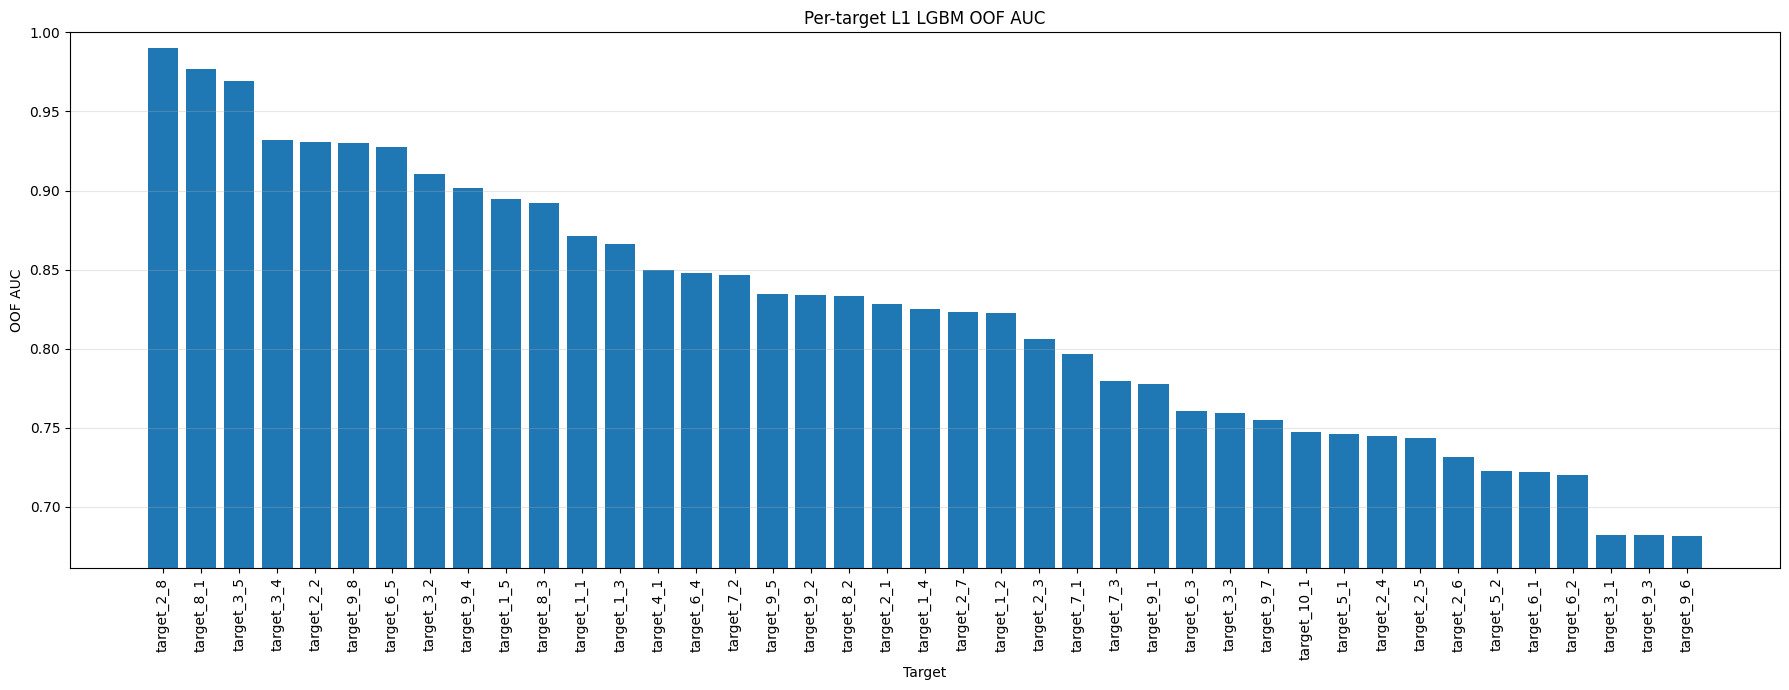

In [26]:
# =========================================
# Visualization: vertical bar chart of per-target OOF AUC
# =========================================
import matplotlib.pyplot as plt

# convert from polars to python lists
plot_df = target_auc_df.sort("oof_auc", descending=True)

targets = plot_df.get_column("target").to_list()
aucs = plot_df.get_column("oof_auc").to_list()

x = np.arange(len(targets))

plt.figure(figsize=(18, 7))
plt.bar(x, aucs)

plt.xticks(x, targets, rotation=90)
plt.ylabel("OOF AUC")
plt.xlabel("Target")
plt.title("Per-target L1 LGBM OOF AUC")
plt.ylim(max(0.0, min(aucs) - 0.02), min(1.0, max(aucs) + 0.02))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# =========================
# Save artifacts
# =========================
oof_path = META_DIR / "l1_lgbm_oof.parquet"
test_path = META_DIR / "l1_lgbm_test.parquet"
scores_path = LOG_DIR / "l1_lgbm_scores.csv"
summary_path = LOG_DIR / "l1_lgbm_summary.json"

oof_df.write_parquet(oof_path)
test_df.write_parquet(test_path)
scores_df.write_csv(scores_path)

summary = {
    "n_train_rows": int(n_train),
    "n_test_rows": int(n_test),
    "n_features": int(len(feature_cols)),
    "n_cat_code_cols": int(len(cat_code_cols)),
    "n_targets": int(n_targets),
    "n_folds": int(len(unique_folds)),
    "macro_oof_auc": float(macro_auc),
    "lgb_params": LGB_PARAMS,
    "num_boost_round": int(NUM_BOOST_ROUND),
    "early_stopping_rounds": int(EARLY_STOPPING_ROUNDS) if EARLY_STOPPING_ROUNDS is not None else None,
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved:")
print(" -", oof_path)
print(" -", test_path)
print(" -", scores_path)
print(" -", summary_path)


Saved:
 - /kaggle/working/prepared/artifacts/meta/l1_lgbm_oof.parquet
 - /kaggle/working/prepared/artifacts/meta/l1_lgbm_test.parquet
 - /kaggle/working/prepared/artifacts/logs/l1_lgbm_scores.csv
 - /kaggle/working/prepared/artifacts/logs/l1_lgbm_summary.json


In [28]:
# =========================
# Final cleanup
# =========================
del X_train, X_test, Y, fold_array, train_ids, test_ids
del oof_preds, test_preds, oof_df, test_df, scores_df
del fold_indices
gc.collect()

print("Notebook 03 finished successfully.")

Notebook 03 finished successfully.
